## **IMPORT LIBRARIES**

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

## **LOAD DATASETS**

In [43]:
clients = pd.read_csv("/content/clients.csv")

properties = pd.read_csv("/content/properties.csv")

## **VIEW DATASETS**

In [44]:
clients.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [45]:
properties.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


## **CHECK SHAPES**

In [46]:
clients.shape

(2000, 12)

In [47]:
properties.shape

(10000, 9)

## **CHECK COLUMN NAMES**

In [48]:
clients.columns

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel'],
      dtype='object')

In [49]:
properties.columns

Index(['listing_id', 'tower_number', 'transaction_date', 'unit_category',
       'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status',
       'client_ref'],
      dtype='object')

## **MERGE BOTH DATASETS**

In [50]:
df = pd.merge(
    clients,
    properties,
    left_on='client_id',
    right_on='client_ref',
    how='inner'
)

In [51]:
df.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,referral_channel,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,90343,9,10-01-2024,Apartment,40,1090.32,"$351,419.29",Sold,C0001
1,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,4051,4,12-01-2024,Apartment,51,1608.84,"$496,266.41",Sold,C0001
2,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,150099,15,05-01-2025,Apartment,15,522.71,"$175,599.90",Sold,C0001
3,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,30432,3,12-01-2025,Apartment,50,713.67,"$223,479.12",Sold,C0001
4,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,150044,15,01-01-2024,Apartment,6,938.57,"$299,245.20",Sold,C0002


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7305 entries, 0 to 7304
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            7305 non-null   object 
 1   client_type          7305 non-null   object 
 2   first_name           7305 non-null   object 
 3   last_name            7305 non-null   object 
 4   date_of_birth        7305 non-null   object 
 5   gender               7305 non-null   object 
 6   country              7305 non-null   object 
 7   region               7305 non-null   object 
 8   acquisition_purpose  7305 non-null   object 
 9   satisfaction_score   7305 non-null   int64  
 10  loan_applied         7305 non-null   object 
 11  referral_channel     7305 non-null   object 
 12  listing_id           7305 non-null   int64  
 13  tower_number         7305 non-null   int64  
 14  transaction_date     7305 non-null   object 
 15  unit_category        7305 non-null   o

In [53]:
print(df.shape)

(7305, 21)


## **CHECK MISSING VALUES**

In [54]:
df.isnull().sum()

,0
client_id,0
client_type,0
first_name,0
last_name,0
date_of_birth,0
gender,0
country,0
region,0
acquisition_purpose,0
satisfaction_score,0


In [55]:
for col in df.select_dtypes(include='object').columns:
  df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include=np.number).columns:df[col] = df[col].fillna(
df[col].mean()
)

print(df.isnull().sum())

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref             0
dtype: int64


## **REMOVE DUPLICATES**

In [56]:
df.drop_duplicates(inplace=True)

## **CONVERT DATE OF BIRTH TO AGE**

In [57]:
df['date_of_birth'] = pd.to_datetime(
    df['date_of_birth'],
    errors='coerce'
)

In [58]:
df['age'] = 2026 - df['date_of_birth'].dt.year

df['age'] = df['age'].fillna(df['age'].median())

## **CLEAN SALE PRICE**

In [59]:
df['sale_price'].head()

,sale_price
0,"$351,419.29"
1,"$496,266.41"
2,"$175,599.90"
3,"$223,479.12"
4,"$299,245.20"


In [60]:
df['sale_price'] = (
df['sale_price']
.astype(str)
.str.replace('$','',regex=False)
.str.replace(',','',regex=False)
)

df['sale_price'] = pd.to_numeric(
df['sale_price'],
errors='coerce'
)

df['sale_price'] = (
df['sale_price']
.fillna(df['sale_price'].median())
)

## **EDA**

In [61]:
print(df.describe())

                       date_of_birth  satisfaction_score     listing_id  \
count                           3118         7305.000000    7305.000000   
mean   1970-11-03 15:59:41.526619628            3.051745  103366.960438   
min              1933-05-05 00:00:00            1.000000    1002.000000   
25%              1956-08-05 00:00:00            2.000000   50360.000000   
50%              1970-01-24 00:00:00            3.000000  100384.000000   
75%              1985-05-01 12:00:00            4.000000  150404.000000   
max              2000-12-09 00:00:00            5.000000  990000.000000   
std                              NaN            1.416073   59757.099261   

       tower_number  unit_number  floor_area_sqft     sale_price          age  
count   7305.000000  7305.000000      7305.000000    7305.000000  7305.000000  
mean      10.360575    29.042437      1141.147838  345072.000115    55.845585  
min        1.000000     1.000000       410.710000   97402.800000    26.000000  
25% 

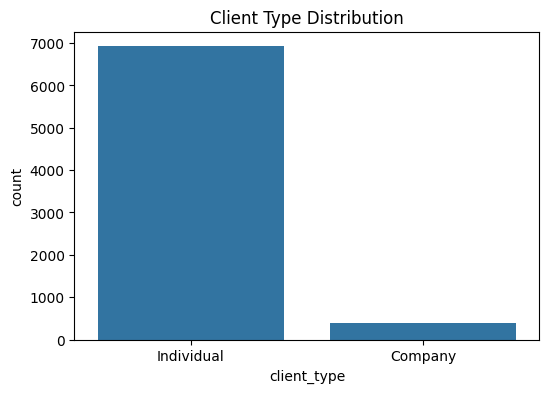

In [70]:
#Client Type

plt.figure(figsize=(6,4))
sns.countplot(data=df,x='client_type')
plt.title("Client Type Distribution")
plt.show()

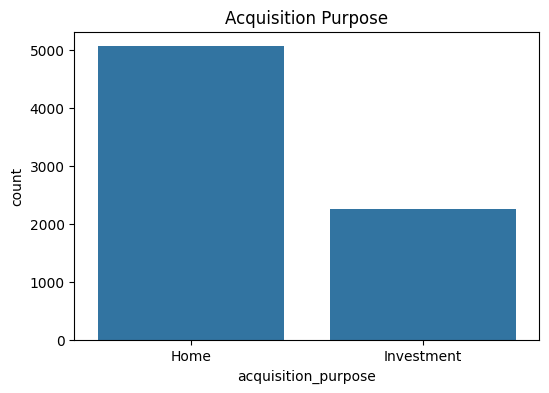

In [71]:
#Acquisition Purpose

plt.figure(figsize=(6,4))
sns.countplot(data=df,x='acquisition_purpose')
plt.title("Acquisition Purpose")
plt.show()

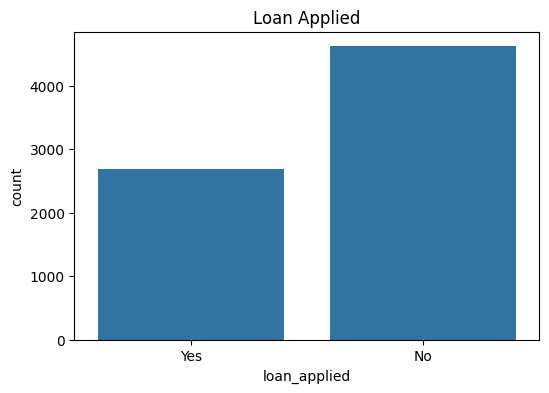

In [72]:
#Loan Applied

plt.figure(figsize=(6,4))
sns.countplot(data=df,x='loan_applied')
plt.title("Loan Applied")
plt.show()

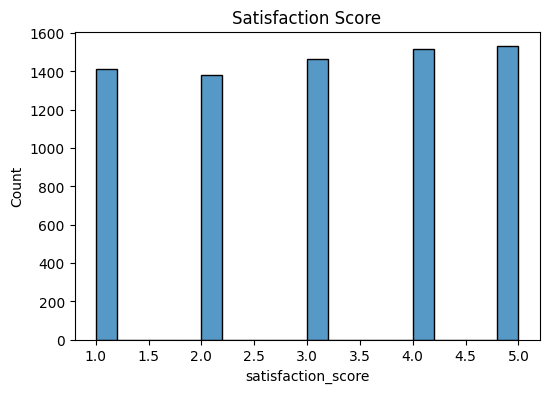

In [73]:
#Satisfaction Score

plt.figure(figsize=(6,4))
sns.histplot(df['satisfaction_score'])
plt.title("Satisfaction Score")
plt.show()

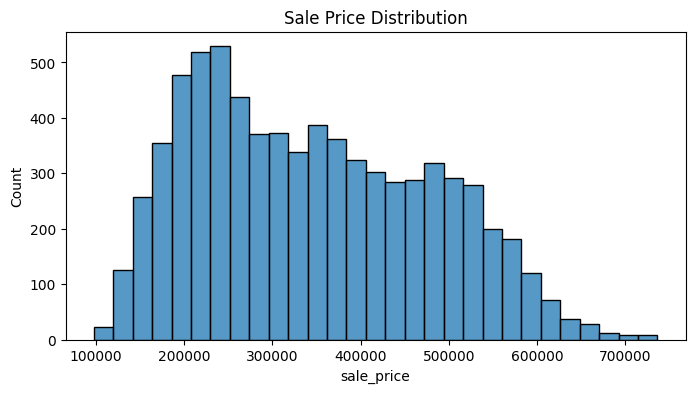

In [74]:
#Sale Price Distribution

plt.figure(figsize=(8,4))
sns.histplot(df['sale_price'])
plt.title("Sale Price Distribution")
plt.show()

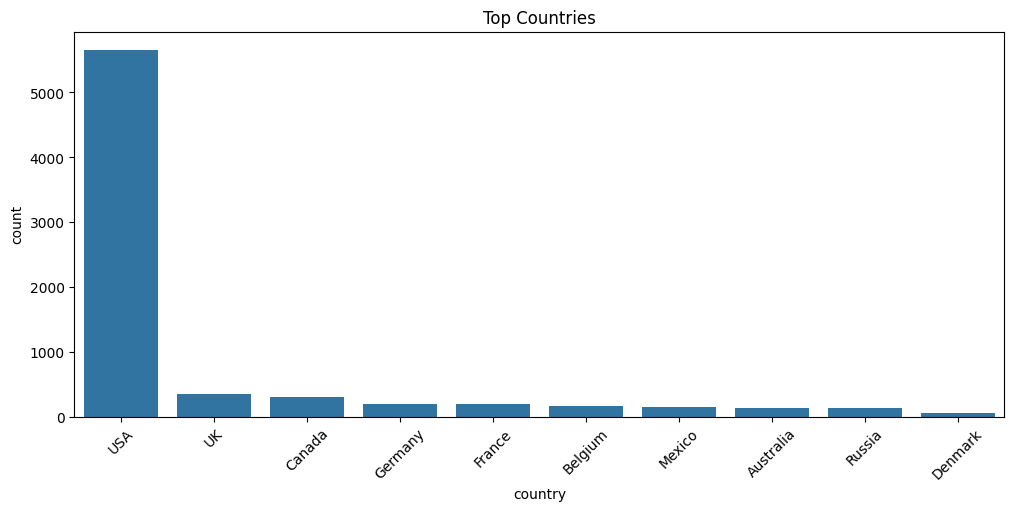

In [76]:
#Top Countries

plt.figure(figsize=(12,5))

sns.countplot(
data=df,
x='country',
order=df['country'].value_counts().head(10).index
)

plt.xticks(rotation=45)
plt.title("Top Countries")
plt.show()


In [77]:
#FEATURE ENCODING
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])

df['loan_applied'] = (
le.fit_transform(df['loan_applied'])
)

df_encoded = pd.get_dummies(
df,
columns=[
'client_type',
'country',
'region',
'acquisition_purpose',
'referral_channel',
'unit_category',
'listing_status'
],
drop_first=True
)

## **DROP UNNECESSARY COLUMNS**

In [78]:
drop_cols = [
'client_id',
'client_ref',
'first_name',
'last_name',
'date_of_birth',
'transaction_date',
'listing_id'
]

for col in drop_cols:
  if col in df_encoded.columns:
    df_encoded.drop(
        col,
        axis=1,
        inplace=True
    )

In [79]:
#Convert Boolean Columns

bool_cols = df_encoded.select_dtypes(
include='bool'
).columns

df_encoded[bool_cols] = (
df_encoded[bool_cols]
.astype(int)
)

In [80]:
#8. FEATURE SCALING

scaler = StandardScaler()

X = scaler.fit_transform(df_encoded)

print(X.shape)

(7305, 78)


In [82]:
#9. ELBOW METHOD
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    wcss.append(model.inertia_)

print(wcss)
print(len(wcss))

[569790.0000000003, 558596.8423052118, 548981.2189742904, 532496.2838691081, 521756.9275544991, 515788.83556885977, 501415.7395745316, 493149.37325547857, 487674.5763723063, 474838.857578769]
10


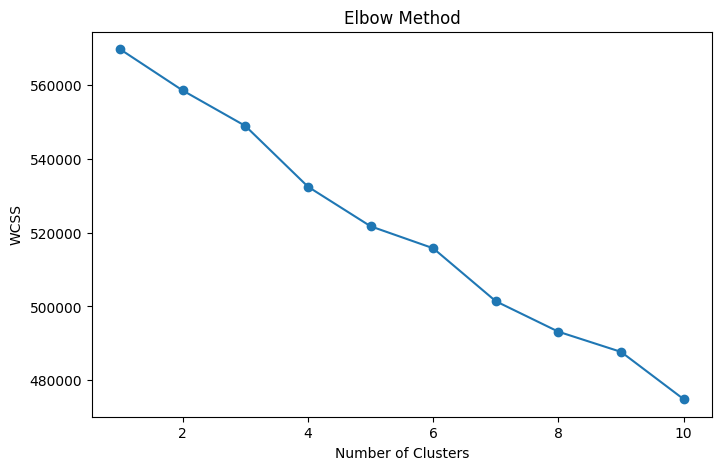

In [83]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [84]:
print(len(wcss))
print(wcss)

10
[569790.0000000003, 558596.8423052118, 548981.2189742904, 532496.2838691081, 521756.9275544991, 515788.83556885977, 501415.7395745316, 493149.37325547857, 487674.5763723063, 474838.857578769]


In [85]:
for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    print(
        "Clusters:",
        i,
        "Score:",
        round(score,4)
    )

Clusters: 2 Score: 0.0308
Clusters: 3 Score: 0.0365
Clusters: 4 Score: 0.0056
Clusters: 5 Score: 0.2719
Clusters: 6 Score: -0.0303
Clusters: 7 Score: 0.0239
Clusters: 8 Score: 0.0433
Clusters: 9 Score: 0.0405
Clusters: 10 Score: 0.0561


In [86]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

In [87]:
print(df['Cluster'].value_counts())

Cluster
1    5656
0    1413
2      97
4      85
3      54
Name: count, dtype: int64


In [88]:
cluster_summary = df.groupby('Cluster').agg({
    'age':'mean',
    'sale_price':'mean',
    'floor_area_sqft':'mean',
    'satisfaction_score':'mean'
})

cluster_summary

,age,sale_price,floor_area_sqft,satisfaction_score
Cluster,,,,
0,54.413305,343083.055534,1138.116674,3.026185
1,56.187235,345302.767118,1141.262857,3.055693
2,57.731959,351889.773814,1151.096598,2.824742
3,51.925926,335865.115556,1125.001852,3.555556
4,57.258824,360848.567647,1182.787176,3.152941


In [89]:
pd.crosstab(df['Cluster'], df['client_type'])

client_type,Company,Individual
Cluster,,
0,66,1347
1,300,5356
2,7,90
3,0,54
4,8,77


In [90]:
pd.crosstab(df['Cluster'], df['acquisition_purpose'])

acquisition_purpose,Home,Investment
Cluster,,
0,952,461
1,3939,1717
2,63,34
3,40,14
4,64,21


In [91]:
pd.crosstab(df['Cluster'], df['loan_applied'])

loan_applied,0,1
Cluster,,
0,880,533
1,3589,2067
2,66,31
3,39,15
4,47,38


In [92]:
pd.crosstab(df['Cluster'], df['country'])

country,Australia,Belgium,Canada,Denmark,France,Germany,Mexico,Russia,UK,USA
Cluster,,,,,,,,,,
0,133,108,300,52,187,195,144,128,166,0
1,0,0,0,0,0,0,0,0,0,5656
2,0,0,0,0,0,0,0,0,97,0
3,0,54,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,85,0


In [93]:
df.to_csv(
    "buyer_segments_output.csv",
    index=False
)